In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import GeneralTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import PutProductMultipleAssets, Put

In [2]:
n_assets = 3

S0 = 2.0
r = 0.1

stds = np.array([0.4, 0.5, 0.6])
correlation_matrix = np.array([
    [1.0, 0.6, 0.3],
    [0.6, 1.0, 0.5],
    [0.3, 0.5, 1.0]
])

sigma = build_covariance_matrix(stds, correlation_matrix)

K = 8.0
T = 1.0
S_min = 0.0
S_max = (3 * K)**(1/3)

market_params = MarketParams(n_assets=3, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
input_size = n_assets + 1
hidden_sizes = [32, 64, 32]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [4]:
put_product = PutProductMultipleAssets()
trainer_product = GeneralTrainer(model_config, market_params, put_product, 67)
trainer_product.train(num_samples=1000, max_iterations=10000, tol=1e-4)

Iteration 0, Loss: 204.4976348876953
Iteration 100, Loss: 20.110027313232422
Iteration 200, Loss: 2.409991502761841
Iteration 300, Loss: 0.9196568131446838
Iteration 400, Loss: 0.43586474657058716
Iteration 500, Loss: 0.29396894574165344
Converged at iteration 522


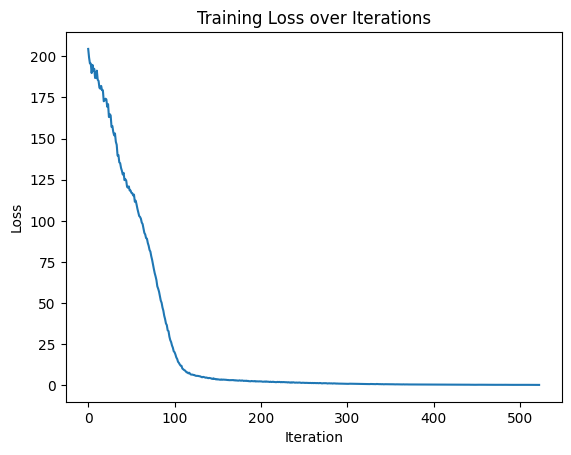

In [5]:
trainer_product.plot_losses()

In [6]:
trainer_product.predict(1, 2, 2, 2).item()

0.6354111433029175

## Compare with 1D case

Iteration 0, Loss: 93.85874938964844
Iteration 100, Loss: 4.4526190757751465
Iteration 200, Loss: 0.32455629110336304
Converged at iteration 283


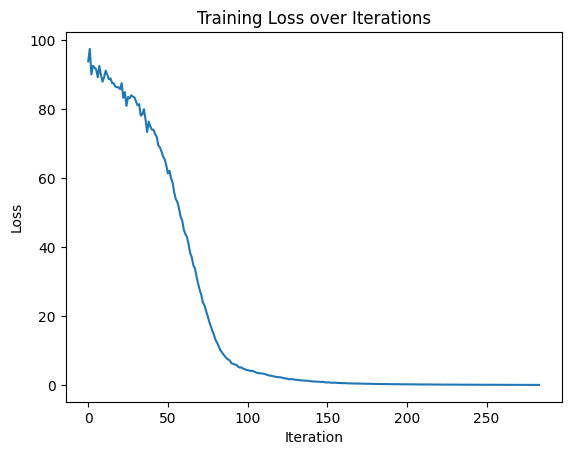

In [21]:
r_prime = n_assets * r + np.sum(np.tril(sigma, k=-1))
sigma_prime = np.sqrt(np.sum(sigma))

market_params_1d = MarketParams(
    n_assets=1,
    S0=S0**n_assets,
    r=r_prime,
    sigma=sigma_prime,
    K=K,
    T=T,
    S_min=S_min**n_assets,
    S_max=S_max**n_assets
)
put_1d = Put()
model_config_1d = ModelConfig(
    input_size=2,
    hidden_sizes=[32, 64, 32],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=0.001
)
trainer_1d = GeneralTrainer(model_config_1d, market_params_1d, put_1d, 67)
trainer_1d.train(num_samples=1000, max_iterations=10000, tol=1e-4)
trainer_1d.plot_losses()

In [22]:
trainer_1d.predict(1, 8).item()

0.2575141489505768